### Cell 1 — Install packages

##### !pip -q install -U pandas numpy pyarrow matplotlib seaborn rapidfuzz tqdm python-dateutil dspy-ai google-genai

### Cell 2 — Imports, paths, and runtime config

In [1]:
# Cell 2 — Imports, paths, and runtime config
from pathlib import Path
import os
import re
import json
import time
import math
import warnings
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm
from rapidfuzz import process, fuzz

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

ROOT_CANDIDATES = [Path("/root/dataset"), Path("root/dataset"), Path("dataset")]
ROOT = next((p for p in ROOT_CANDIDATES if p.exists()), None)
assert ROOT is not None, "Could not find dataset folder."

NMAT_PATH  = ROOT / "NMAT_CLEANED_DATA.csv"
CEM_PATH   = ROOT / "CEM_DATA.csv"
UNIVS_PATH = ROOT / "UNIVS.csv"

assert NMAT_PATH.exists(),  f"Missing: {NMAT_PATH}"
assert CEM_PATH.exists(),   f"Missing: {CEM_PATH}"
assert UNIVS_PATH.exists(), f"Missing: {UNIVS_PATH}"

OUTDIR = ROOT / "output"
OUTDIR.mkdir(parents=True, exist_ok=True)

DSPY_VERIFIED_PATH = ROOT / "DsPy_verified.csv"
FINAL_PATH         = ROOT / "NMAT_FINAL.csv"

# -------------------------------------------------------------------
# MATCHING CONFIG — UNIVS.csv is the sole source of truth
# No Gemini, no web search, no API calls
# -------------------------------------------------------------------
FUZZY_MATCH_MIN_SCORE = 88   # Minimum fuzzy score to accept a match
FUZZY_MATCH_MIN_GAP   = 5    # Top match must beat 2nd place by this margin

print("ROOT:", ROOT)
print("NMAT_PATH:", NMAT_PATH)
print("UNIVS_PATH:", UNIVS_PATH)
print("DSPY_VERIFIED_PATH:", DSPY_VERIFIED_PATH)
print("FUZZY_MATCH_MIN_SCORE:", FUZZY_MATCH_MIN_SCORE)

ROOT: dataset
NMAT_PATH: dataset\NMAT_CLEANED_DATA.csv
UNIVS_PATH: dataset\UNIVS.csv
DSPY_VERIFIED_PATH: dataset\DsPy_verified.csv
FUZZY_MATCH_MIN_SCORE: 88


d:\User\Desktop\Acads\NMAT Analysis\NMAT_Analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Cell 3 — Helper functions

In [2]:
def clean_text(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x if x else np.nan

def normalize_text(x):
    x = clean_text(x)
    if pd.isna(x):
        return np.nan
    x = x.upper()
    x = re.sub(r"[^A-Z0-9 ]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def clean_appno(x):
    x = clean_text(x)
    if pd.isna(x):
        return np.nan
    x = re.sub(r"\D", "", str(x))
    return x if x else np.nan

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

def infer_uni_location(uni_type, university):
    uni_type = clean_text(uni_type)
    university = clean_text(university)
    if pd.isna(uni_type) and pd.isna(university):
        return np.nan
    if str(uni_type).strip().lower() == "foreign":
        return "International"
    return "Local"

def map_course_group(text):
    text = normalize_text(text)
    if pd.isna(text):
        return "Other"

    med_keywords = ["MEDICAL", "ALLIED", "NURSING", "PHARMACY", "HEALTH", "MED TECHNOLOGY", "RADIOLOGIC", "PUBLIC HEALTH", "NUTRITION"]
    nat_keywords = ["BIOLOGY", "NATURAL SCIENCE", "NATURAL SCIENCES", "PHYSICS", "CHEMISTRY"]
    soc_keywords = ["SOCIAL", "BEHAVIORAL", "BEHAVIOURAL", "PSYCHOLOGY", "ECONOMICS"]
    eng_keywords = ["ENGINEERING", "TECHNOLOGY"]
    edu_keywords = ["EDUCATION", "TEACHER"]

    if any(k in text for k in med_keywords):
        return "Medical & Allied"
    if any(k in text for k in nat_keywords):
        return "Natural Sciences"
    if any(k in text for k in soc_keywords):
        return "Social & Behavioral Sciences"
    if any(k in text for k in eng_keywords):
        return "Engineering & Technology"
    if any(k in text for k in edu_keywords):
        return "Education"
    return "Other"

def derive_course_group(row):
    candidates = [
        row.get("Course Classification"),
        row.get("Course_recode"),
        row.get("NMA_Course"),
        row.get("COURSE_DESC")
    ]
    for c in candidates:
        if pd.notna(c):
            grp = map_course_group(c)
            if grp != "Other":
                return grp
    return "Other"

def exact_or_null(df, key_col, key_val):
    if pd.isna(key_val):
        return pd.DataFrame(columns=df.columns)
    out = df[df[key_col] == key_val].copy()
    return out

def safe_json(obj):
    try:
        return json.dumps(obj, ensure_ascii=False)
    except Exception:
        return str(obj)

### Cell 4 — Load source files

In [3]:
nmat = pd.read_csv(NMAT_PATH, dtype=str, low_memory=False)
cem = pd.read_csv(CEM_PATH, dtype=str, low_memory=False)
univs = pd.read_csv(UNIVS_PATH, dtype=str, low_memory=False)

print("NMAT shape:", nmat.shape)
print("CEM shape:", cem.shape)
print("UNIVS shape:", univs.shape)

NMAT shape: (178927, 29)
CEM shape: (254308, 36)
UNIVS shape: (3022, 8)


### Cell 5 — Standardize columns and keys

In [4]:
# Clean column names first
nmat.columns = [clean_text(c) for c in nmat.columns]
cem.columns = [clean_text(c) for c in cem.columns]
univs.columns = [clean_text(c) for c in univs.columns]

def rename_columns_by_alias(df, alias_map):
    current_cols = list(df.columns)
    normalized_lookup = {
        re.sub(r"[^A-Z0-9]+", "", str(c).upper()): c
        for c in current_cols
    }

    rename_dict = {}
    for canonical, aliases in alias_map.items():
        candidates = [canonical] + aliases
        for alias in candidates:
            key = re.sub(r"[^A-Z0-9]+", "", str(alias).upper())
            if key in normalized_lookup:
                rename_dict[normalized_lookup[key]] = canonical
                break

    return df.rename(columns=rename_dict)

# -------------------------------------------------------------------
# Column alias maps: raw file headers -> canonical headers used below
# -------------------------------------------------------------------
nmat_aliases = {
    "NMA_TestDate": ["NMATestDate"],
    "NMC_Center": ["NMCCenter"],
    "NMA_AppNo": ["NMAAppNo"],
    "NMA_Name": ["NMAName"],
    "NMA_Course": ["NMACourse"],
    "NMA_Sex": ["NMASex"],
    "NMA_BirthDate": ["NMABirthDate"],
    "NAC_NATIONALITY": ["NACNATIONALITY"],
    "NMA_Graduating": ["NMAGraduating"],
    "NMA_YearGrad": ["NMAYearGrad"],
    "NMS_VCss": ["NMSVCss"],
    "NMS_IRss": ["NMSIRss"],
    "NMS_Qss": ["NMSQss"],
    "NMS_PAss": ["NMSPAss"],
    "NMS_BIOss": ["NMSBIOss"],
    "NMS_PHYss": ["NMSPHYss"],
    "NMS_SSCss": ["NMSSSCss"],
    "NMS_CHEMss": ["NMSCHEMss"],
    "NMS_APT": ["NMSAPT"],
    "NMS_SA": ["NMSSA"],
    "NMS_GPS": ["NMSGPS"],
    "NMS_PER": ["NMSPER"],
    "NMA_College": ["NMACollege"],
    "School Type_rec2_FINAL": ["School Typerec2FINAL", "SchoolTypeRec2FINAL"],
    "Course_recode": ["Courserecode", "CourseRecode"]
}

cem_aliases = {
    "STU_NO": ["STUNO", "StuNo"],
    "COLLEGE_NAME": ["COLLEGENAME", "CollegeName"],
    "COURSE_DESC": ["COURSEDESC", "CourseDesc"],
    "STU_TESTDATE": ["STUTESTDATE", "StuTestDate"],
    "STU_RS_CA01": ["STURSCA01", "StuRSCA01"],
    "STU_RS_CA02": ["STURSCA02", "StuRSCA02"],
    "STU_RS_CA03": ["STURSCA03", "StuRSCA03"],
    "STU_RS_CA04": ["STURSCA04", "StuRSCA04"],
    "STU_RS_CA05": ["STURSCA05", "StuRSCA05"],
    "STU_RS_CA06": ["STURSCA06", "StuRSCA06"],
    "STU_RS_CA07": ["STURSCA07", "StuRSCA07"],
    "STU_RS_CA08": ["STURSCA08", "StuRSCA08"],
    "STU_RSCORE": ["STURSCORE", "StuRScore"],
    "STU_RSCORE_CALC": ["STURSCORECALC", "StuRScoreCalc"],
    "STU_RSCORE_VALID": ["STURSCOREVALID", "StuRScoreValid"],
    "STU_SS_CA01": ["STUSSCA01", "StuSSCA01"],
    "STU_SS_CA02": ["STUSSCA02", "StuSSCA02"],
    "STU_SS_CA03": ["STUSSCA03", "StuSSCA03"],
    "STU_SS_CA04": ["STUSSCA04", "StuSSCA04"],
    "STU_SS_CA05": ["STUSSCA05", "StuSSCA05"],
    "STU_SS_CA06": ["STUSSCA06", "StuSSCA06"],
    "STU_SS_CA07": ["STUSSCA07", "StuSSCA07"],
    "STU_SS_CA08": ["STUSSCA08", "StuSSCA08"],
    "STU_SS_APT": ["STUSSAPT", "StuSSAPT"],
    "STU_SS_SA": ["STUSSSA", "StuSSSA"],
    "STU_SSCORE": ["STUSSCORE", "StuSScore"],
    "STU_PRANK": ["STUPRANK", "StuPRank"],
    "NMAT_YEAR": ["NMATYEAR"]
}

univs_aliases = {
    "NMA_College": ["NMACollege"],
    "NMA_College_UPPER": ["NMACollegeUPPER"],
    "COLLEGE_UNIV": ["COLLEGEUNIV"],
    "LOCATION_1": ["LOCATION1"],
    "LOCATION_2": ["LOCATION2"],
    "UNI_TYPE": ["UNITYPE"],
    "UNI_LOCATION": ["UNILOCATION"]
}

nmat = rename_columns_by_alias(nmat, nmat_aliases)
cem = rename_columns_by_alias(cem, cem_aliases)
univs = rename_columns_by_alias(univs, univs_aliases)

# Early assertions so failures happen clearly
required_nmat = ["NMA_AppNo", "NMA_College", "School Type_rec2_FINAL"]
required_cem = ["STU_NO", "COLLEGE_NAME"]
required_univs = ["NMA_College", "UNIVERSITY", "UNI_TYPE", "UNI_LOCATION"]

missing_nmat = [c for c in required_nmat if c not in nmat.columns]
missing_cem = [c for c in required_cem if c not in cem.columns]
missing_univs = [c for c in required_univs if c not in univs.columns]

assert not missing_nmat, f"NMAT missing required columns after standardization: {missing_nmat}"
assert not missing_cem, f"CEM missing required columns after standardization: {missing_cem}"
assert not missing_univs, f"UNIVS missing required columns after standardization: {missing_univs}"

# Preserve provenance
nmat["SOURCE_NMAT"] = "NMAT_CLEANED_DATA"
cem["SOURCE_CEM"] = "CEM_DATA"
univs["SOURCE_UNIVS"] = "UNIVS"

# Clean important raw text columns
for col in ["NMA_College", "NMA_Name", "NMA_Course", "Course Classification", "Course_recode", "School Type_rec2_FINAL"]:
    if col in nmat.columns:
        nmat[col] = nmat[col].map(clean_text)

for col in ["COLLEGE_NAME", "COURSE_DESC", "STU_RSCORE_VALID"]:
    if col in cem.columns:
        cem[col] = cem[col].map(clean_text)

for col in ["NMA_College", "NMA_College_UPPER", "COLLEGE_UNIV", "LOCATION_1", "LOCATION_2", "UNIVERSITY", "UNI_TYPE", "UNI_LOCATION"]:
    if col in univs.columns:
        univs[col] = univs[col].map(clean_text)

# Join keys
nmat["NMA_AppNo_clean"] = nmat["NMA_AppNo"].map(clean_appno)
cem["STU_NO_clean"] = cem["STU_NO"].map(clean_appno)

# College normalization
nmat["NMA_College_norm"] = nmat["NMA_College"].map(normalize_text)
cem["COLLEGE_NAME_norm"] = cem["COLLEGE_NAME"].map(normalize_text)

if "NMA_College_UPPER" in univs.columns:
    univs["NMA_College_norm"] = univs["NMA_College_UPPER"].fillna(univs["NMA_College"]).map(normalize_text)
else:
    univs["NMA_College_norm"] = univs["NMA_College"].map(normalize_text)

# Numeric NMAT fields
for col in ["Year", "NMS_VCss", "NMS_IRss", "NMS_Qss", "NMS_PAss", "NMS_BIOss", "NMS_PHYss", "NMS_SSCss", "NMS_CHEMss", "NMS_APT", "NMS_SA", "NMS_GPS", "NMS_PER"]:
    if col in nmat.columns:
        nmat[col] = nmat[col].map(clean_text)

audit_counts = pd.DataFrame({
    "dataset": ["NMAT_CLEANED_DATA", "CEM_DATA", "UNIVS"],
    "rows": [len(nmat), len(cem), len(univs)],
    "unique_join_keys": [
        nmat["NMA_AppNo_clean"].nunique(dropna=True),
        cem["STU_NO_clean"].nunique(dropna=True),
        np.nan
    ]
})

audit_counts.to_csv(OUTDIR / "00_source_counts.csv", index=False)
audit_counts

,dataset,rows,unique_join_keys
0,NMAT_CLEANED_DATA,178927,178926.0
1,CEM_DATA,254308,254304.0
2,UNIVS,3022,NaN


### Cell 6 — Visualize source counts and duplicate keys

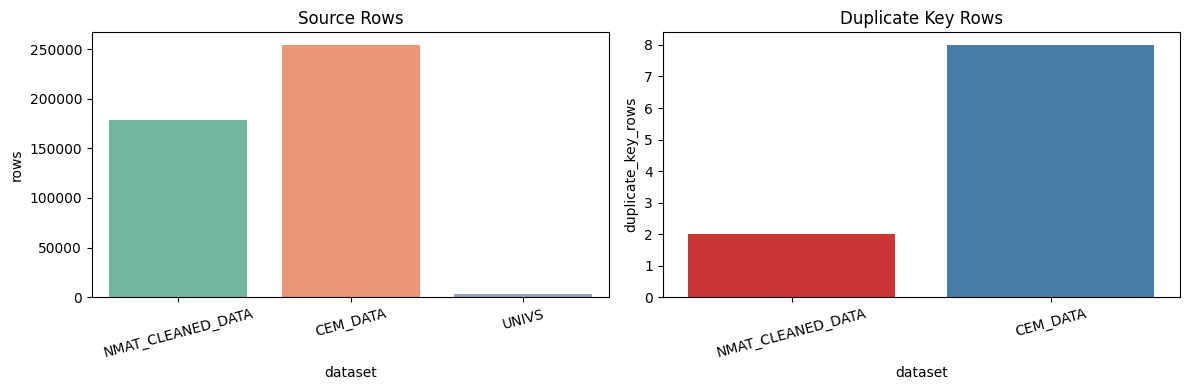

,dataset,duplicate_key_rows
0,NMAT_CLEANED_DATA,2
1,CEM_DATA,8


In [5]:
nmat_dup_keys = nmat["NMA_AppNo_clean"].duplicated(keep=False).sum()
cem_dup_keys = cem["STU_NO_clean"].duplicated(keep=False).sum()

dup_summary = pd.DataFrame({
    "dataset": ["NMAT_CLEANED_DATA", "CEM_DATA"],
    "duplicate_key_rows": [nmat_dup_keys, cem_dup_keys]
})
dup_summary.to_csv(OUTDIR / "01_duplicate_key_summary.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=audit_counts, x="dataset", y="rows", ax=axes[0], palette="Set2")
axes[0].set_title("Source Rows")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=dup_summary, x="dataset", y="duplicate_key_rows", ax=axes[1], palette="Set1")
axes[1].set_title("Duplicate Key Rows")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(OUTDIR / "02_source_audit.png", dpi=200, bbox_inches="tight")
plt.show()

dup_summary

### Cell 7 — Build unique college list to verify once

In [6]:
college_dim = (
    nmat[["NMA_College", "NMA_College_norm", "School Type_rec2_FINAL"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

college_dim["nmat_count"] = college_dim["NMA_College"].map(
    nmat["NMA_College"].value_counts(dropna=False)
)

college_dim.to_csv(OUTDIR / "03_unique_college_dim.csv", index=False)
college_dim.head(20)

,NMA_College,NMA_College_norm,School Type_rec2_FINAL,nmat_count
0,University Of Santo Tomas,UNIVERSITY OF SANTO TOMAS,Private,25336
1,Ateneo De Manila University,ATENEO DE MANILA UNIVERSITY,Private,939
2,University Of The Philippines - Diliman,UNIVERSITY OF THE PHILIPPINES DILIMAN,Public,4416
3,Adventist University Of The Philippines,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,905
4,De La Salle University - Manila,DE LA SALLE UNIVERSITY MANILA,Private,2979
5,University Of The Philippines - Baguio City,UNIVERSITY OF THE PHILIPPINES BAGUIO CITY,Public,240
6,"Far Eastern University - Nrmf (Fairview, Q.C.)",FAR EASTERN UNIVERSITY NRMF FAIRVIEW Q C,Private,469
7,"University Of San Carlos, Cebu City",UNIVERSITY OF SAN CARLOS CEBU CITY,Private,167
8,"Centro Escolar University - Mendiola, Manila",CENTRO ESCOLAR UNIVERSITY MENDIOLA MANILA,Private,445
9,University Of The Philippines - Manila,UNIVERSITY OF THE PHILIPPINES MANILA,Public,4890


### Cell 8 — Prepare UNIVS lookup tables

In [7]:
# Cell 8 — Prepare UNIVS lookup (simplified — exact_univs no longer needed)

univs_work = univs.copy()

keep_cols = [c for c in [
    "NMA_College",
    "NMA_College_norm",
    "COLLEGE_UNIV",
    "LOCATION_1",
    "LOCATION_2",
    "UNIVERSITY",
    "UNI_TYPE",
    "UNI_LOCATION"
] if c in univs_work.columns]

univs_work = univs_work[keep_cols].drop_duplicates().reset_index(drop=True)

for col in ["UNIVERSITY", "UNI_TYPE", "UNI_LOCATION", "COLLEGE_UNIV", "LOCATION_1", "LOCATION_2"]:
    if col in univs_work.columns:
        univs_work[col] = univs_work[col].map(clean_text)

print("UNIVS hint table prepared.")
print("UNIVS unique normalized keys:", univs_work["NMA_College_norm"].nunique(dropna=True))
univs_work.head(10)

UNIVS hint table prepared.
UNIVS unique normalized keys: 2969


,NMA_College,NMA_College_norm,COLLEGE_UNIV,LOCATION_1,LOCATION_2,UNIVERSITY,UNI_TYPE,UNI_LOCATION
0,4493 SARVODAYA COLLEGE OF NURSING NAGAUR,4493 SARVODAYA COLLEGE OF NURSING NAGAUR,4493 SARVODAYA COLLEGE OF NURSING NAGAUR,NaN,NaN,4493 SARVODAYA COLLEGE OF NURSING NAGAUR,Foreign,International
1,AADHRIYA EDUCATIONAL FOUNDATION,AADHRIYA EDUCATIONAL FOUNDATION,AADHRIYA EDUCATIONAL FOUNDATION,NaN,NaN,AADHRIYA EDUCATIONAL FOUNDATION,Foreign,International
2,Aakash institute,AAKASH INSTITUTE,AAKASH INSTITUTE,NaN,NaN,AAKASH INSTITUTE,Foreign,International
3,AARON PUBLIC SCHOOL,AARON PUBLIC SCHOOL,AARON PUBLIC SCHOOL,NaN,NaN,AARON PUBLIC SCHOOL,Foreign,International
4,AASTHA ACADEMY SR SEC SCH NAWALGARH ROAD,AASTHA ACADEMY SR SEC SCH NAWALGARH ROAD,AASTHA ACADEMY SR SEC SCH NAWALGARH ROAD,NaN,NaN,AASTHA ACADEMY SR SEC SCH NAWALGARH ROAD,Foreign,International
5,Abada College,ABADA COLLEGE,ABADA COLLEGE,NaN,NaN,ABADA COLLEGE,Private,Local
6,Abada College - Pinamalayan Oriental Mindoro,ABADA COLLEGE PINAMALAYAN ORIENTAL MINDORO,ABADA COLLEGE,PINAMALAYAN ORIENTAL MINDORO,NaN,ABADA COLLEGE - PINAMALAYAN ORIENTAL MINDORO,Private,Local
7,ABDUL RAZAQ MEMORIAL DEGREE COLLEGE,ABDUL RAZAQ MEMORIAL DEGREE COLLEGE,ABDUL RAZAQ MEMORIAL DEGREE COLLEGE,NaN,NaN,ABDUL RAZAQ MEMORIAL DEGREE COLLEGE,Foreign,International
8,ABE International Coll of Busand Econ - Bacolo...,ABE INTERNATIONAL COLL OF BUSAND ECON BACOLOD ...,ABE INTERNATIONAL COLL OF BUSAND ECON,BACOLOD,BACOLOD CITY NEGROS OCCIDENTAL,ABE INTERNATIONAL COLL OF BUSAND ECON - BACOLO...,Private,Local
9,ABE International College of Business and Acco...,ABE INTERNATIONAL COLLEGE OF BUSINESS AND ACCO...,ABE INTERNATIONAL COLLEGE OF BUSINESS AND ACCO...,CEBU CITY CEBU,NaN,ABE INTERNATIONAL COLLEGE OF BUSINESS AND ACCO...,Private,Local


### Cell 9 — Deterministic exact pass from UNIVS

In [8]:
# Cell 9 — UNIVS-only university matching
# Produces verified_dim with UNIVERSITY, UNI_TYPE, UNI_LOCATION for every NMA_College

# -------------------------------------------------------------------
# Canonicalization helpers (used here and in Cell 15)
# -------------------------------------------------------------------
def canon_uni_type_final(x, fallback=None):
    x        = clean_text(x)
    fallback = clean_text(fallback)
    valid = {
        "PUBLIC":        "Public",
        "PRIVATE":       "Private",
        "FOREIGN":       "Foreign",
        "NOT SPECIFIED": "Not Specified"
    }
    if pd.notna(x) and x.upper() in valid:
        return valid[x.upper()]
    if pd.notna(fallback) and fallback.upper() in valid:
        return valid[fallback.upper()]
    return "Not Specified"

def canon_uni_location_final(x, uni_type=None):
    x        = clean_text(x)
    uni_type = clean_text(uni_type)
    if pd.notna(x):
        xu = x.upper()
        if xu == "LOCAL":         return "Local"
        if xu == "INTERNATIONAL": return "International"
        if xu == "UNKNOWN":       return "Unknown"
    if pd.notna(uni_type):
        if uni_type.lower() == "foreign":             return "International"
        if uni_type.lower() in ("public", "private"): return "Local"
    return "Unknown"

# -------------------------------------------------------------------
# Build UNIVS lookup tables
# Primary key:   NMA_College_norm  (matches raw NMAT NMA_College)
# Secondary key: COLLEGE_UNIV_norm (canonical university name in UNIVS)
# -------------------------------------------------------------------
univs_hint = univs_work.copy()

for col in ["UNIVERSITY", "UNI_TYPE", "UNI_LOCATION", "COLLEGE_UNIV", "LOCATION_1", "LOCATION_2"]:
    if col in univs_hint.columns:
        univs_hint[col] = univs_hint[col].map(clean_text)

univs_hint = univs_hint.dropna(subset=["NMA_College_norm"]).copy()

# Build COLLEGE_UNIV normalized key if column exists
if "COLLEGE_UNIV" in univs_hint.columns:
    univs_hint["COLLEGE_UNIV_norm"] = univs_hint["COLLEGE_UNIV"].map(normalize_text)
else:
    univs_hint["COLLEGE_UNIV_norm"] = np.nan

# Primary lookup: NMA_College_norm → records
univs_by_norm = {
    norm: grp.drop_duplicates().to_dict("records")
    for norm, grp in univs_hint.groupby("NMA_College_norm", dropna=True)
}

# Secondary lookup: COLLEGE_UNIV_norm → records
univs_by_college_univ = {}
if "COLLEGE_UNIV_norm" in univs_hint.columns:
    for norm, grp in univs_hint.dropna(subset=["COLLEGE_UNIV_norm"]).groupby("COLLEGE_UNIV_norm", dropna=True):
        univs_by_college_univ[norm] = grp.drop_duplicates().to_dict("records")

# All normalized keys for fuzzy matching (primary only)
univs_norm_choices = sorted(univs_by_norm.keys())

print(f"UNIVS primary keys (NMA_College_norm):  {len(univs_norm_choices):,}")
print(f"UNIVS secondary keys (COLLEGE_UNIV_norm): {len(univs_by_college_univ):,}")

# -------------------------------------------------------------------
# Core matching function
# Order: (1) exact primary → (2) exact secondary → (3) fuzzy → (4) unmatched
# -------------------------------------------------------------------
def _best_candidate(candidates: list) -> dict:
    """Pick the best record from a list — prefer one with UNIVERSITY populated."""
    for c in candidates:
        if pd.notna(clean_text(c.get("UNIVERSITY"))):
            return c
    return candidates[0] if candidates else {}

def match_college_to_univs(raw_college: str, school_type_hint: str) -> dict:
    """
    Match one NMA_College value to UNIVS and return all verified fields.
    Returns UNMATCHED with 'Not Specified' / 'Unknown' if nothing found.
    """
    key = normalize_text(raw_college)

    unmatched = {
        "UNIVERSITY":          clean_text(raw_college) or "Unspecified",
        "UNI_TYPE":            "Not Specified",
        "UNI_LOCATION":        "Unknown",
        "UNIVERSITY_VERIFIED": np.nan,
        "UNI_TYPE_VERIFIED":   np.nan,
        "UNI_LOCATION_VERIFIED": np.nan,
        "final_value_source":  "FALLBACK_UNSPECIFIED",
        "verification_method": "NO_UNIVS_MATCH",
        "verification_status": "UNMATCHED",
        "confidence":          "0",
        "evidence_summary":    "No match found in UNIVS.csv — original NMA_College retained as-is.",
        "draft_university":    np.nan,
        "draft_uni_type":      np.nan,
        "draft_uni_location":  np.nan,
        "draft_hint_method":   np.nan,
        "draft_hint_score":    np.nan,
    }

    if pd.isna(key):
        return unmatched

    candidates  = []
    match_method = None
    match_score  = 0

    # (1) Exact primary match: NMA_College_norm
    if key in univs_by_norm:
        candidates   = univs_by_norm[key]
        match_method = "UNIVS_EXACT_PRIMARY"
        match_score  = 100

    # (2) Exact secondary match: COLLEGE_UNIV_norm
    elif key in univs_by_college_univ:
        candidates   = univs_by_college_univ[key]
        match_method = "UNIVS_EXACT_SECONDARY"
        match_score  = 100

    # (3) Fuzzy match on primary keys
    else:
        hits = process.extract(
            key,
            univs_norm_choices,
            scorer=fuzz.token_sort_ratio,
            limit=2
        )
        if hits:
            top_norm, top_score, _ = hits[0]
            second_score = hits[1][1] if len(hits) > 1 else 0
            gap = top_score - second_score

            if top_score >= FUZZY_MATCH_MIN_SCORE and gap >= FUZZY_MATCH_MIN_GAP:
                candidates   = univs_by_norm.get(top_norm, [])
                match_method = "UNIVS_FUZZY"
                match_score  = int(round(top_score))

    # No match after all three attempts
    if not candidates:
        return unmatched

    best = _best_candidate(candidates)

    raw_type = clean_text(best.get("UNI_TYPE"))
    raw_loc  = clean_text(best.get("UNI_LOCATION"))
    uni_val  = clean_text(best.get("UNIVERSITY")) or clean_text(raw_college) or "Unspecified"

    uni_type = canon_uni_type_final(raw_type, school_type_hint)
    uni_loc  = canon_uni_location_final(raw_loc, uni_type)

    return {
        "UNIVERSITY":            uni_val,
        "UNI_TYPE":              uni_type,
        "UNI_LOCATION":          uni_loc,
        "UNIVERSITY_VERIFIED":   uni_val,
        "UNI_TYPE_VERIFIED":     uni_type,
        "UNI_LOCATION_VERIFIED": uni_loc,
        "final_value_source":    "UNIVS_MATCHED",
        "verification_method":   match_method,
        "verification_status":   "VERIFIED",
        "confidence":            str(match_score),
        "evidence_summary":      f"Matched from UNIVS.csv via {match_method} (score={match_score}).",
        "draft_university":      uni_val,
        "draft_uni_type":        uni_type,
        "draft_uni_location":    uni_loc,
        "draft_hint_method":     match_method,
        "draft_hint_score":      match_score,
    }

# -------------------------------------------------------------------
# Run matching for all unique colleges
# -------------------------------------------------------------------
records = []
for _, row in tqdm(college_dim.iterrows(), total=len(college_dim), desc="Matching colleges"):
    m = match_college_to_univs(
        raw_college      = row["NMA_College"],
        school_type_hint = row.get("School Type_rec2_FINAL")
    )
    records.append({
        "NMA_College":             row["NMA_College"],
        "NMA_College_norm":        row["NMA_College_norm"],
        "School Type_rec2_FINAL":  row.get("School Type_rec2_FINAL"),
        "nmat_count":              row.get("nmat_count"),
        **m
    })

verified_dim = pd.DataFrame(records)
verified_dim.to_csv(DSPY_VERIFIED_PATH, index=False)

# Summary
total     = len(verified_dim)
matched   = (verified_dim["verification_status"] == "VERIFIED").sum()
unmatched = (verified_dim["verification_status"] == "UNMATCHED").sum()

print(f"\n{'='*55}")
print(f"UNIVS MATCHING COMPLETE")
print(f"{'='*55}")
print(f"Total unique colleges:  {total:,}")
print(f"Matched (VERIFIED):     {matched:,}  ({matched/total*100:.1f}%)")
print(f"Unmatched (flagged):    {unmatched:,}  ({unmatched/total*100:.1f}%)")
print(f"\nBy method:")
print(verified_dim["verification_method"].value_counts(dropna=False).to_string())
print(f"\nSaved: {DSPY_VERIFIED_PATH}")

verified_dim.head(20)

UNIVS primary keys (NMA_College_norm):  2,969
UNIVS secondary keys (COLLEGE_UNIV_norm): 2,311


Matching colleges: 100%|██████████| 4367/4367 [00:04<00:00, 957.68it/s] 



UNIVS MATCHING COMPLETE
Total unique colleges:  4,367
Matched (VERIFIED):     2,981  (68.3%)
Unmatched (flagged):    1,386  (31.7%)

By method:
verification_method
UNIVS_EXACT_PRIMARY      2674
NO_UNIVS_MATCH           1386
UNIVS_FUZZY               235
UNIVS_EXACT_SECONDARY      72

Saved: dataset\DsPy_verified.csv


,NMA_College,NMA_College_norm,School Type_rec2_FINAL,nmat_count,UNIVERSITY,UNI_TYPE,UNI_LOCATION,UNIVERSITY_VERIFIED,UNI_TYPE_VERIFIED,UNI_LOCATION_VERIFIED,final_value_source,verification_method,verification_status,confidence,evidence_summary,draft_university,draft_uni_type,draft_uni_location,draft_hint_method,draft_hint_score
0,University Of Santo Tomas,UNIVERSITY OF SANTO TOMAS,Private,25336,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVS_EXACT_PRIMARY,100.0
1,Ateneo De Manila University,ATENEO DE MANILA UNIVERSITY,Private,939,ATENEO DE MANILA UNIVERSITY,Private,Local,ATENEO DE MANILA UNIVERSITY,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,ATENEO DE MANILA UNIVERSITY,Private,Local,UNIVS_EXACT_PRIMARY,100.0
2,University Of The Philippines - Diliman,UNIVERSITY OF THE PHILIPPINES DILIMAN,Public,4416,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_EXACT_PRIMARY,100.0
3,Adventist University Of The Philippines,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,905,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,UNIVS_EXACT_PRIMARY,100.0
4,De La Salle University - Manila,DE LA SALLE UNIVERSITY MANILA,Private,2979,DE LA SALLE UNIVERSITY - MANILA,Private,Local,DE LA SALLE UNIVERSITY - MANILA,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,DE LA SALLE UNIVERSITY - MANILA,Private,Local,UNIVS_EXACT_PRIMARY,100.0
5,University Of The Philippines - Baguio City,UNIVERSITY OF THE PHILIPPINES BAGUIO CITY,Public,240,UNIVERSITY OF THE PHILIPPINES - BAGUIO CITY,Public,Local,UNIVERSITY OF THE PHILIPPINES - BAGUIO CITY,Public,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF THE PHILIPPINES - BAGUIO CITY,Public,Local,UNIVS_EXACT_PRIMARY,100.0
6,"Far Eastern University - Nrmf (Fairview, Q.C.)",FAR EASTERN UNIVERSITY NRMF FAIRVIEW Q C,Private,469,FAR EASTERN UNIVERSITY - NRMF (FAIRVIEW Q.C.),Private,Local,FAR EASTERN UNIVERSITY - NRMF (FAIRVIEW Q.C.),Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,FAR EASTERN UNIVERSITY - NRMF (FAIRVIEW Q.C.),Private,Local,UNIVS_EXACT_PRIMARY,100.0
7,"University Of San Carlos, Cebu City",UNIVERSITY OF SAN CARLOS CEBU CITY,Private,167,UNIVERSITY OF SAN CARLOS CEBU CITY,Private,Local,UNIVERSITY OF SAN CARLOS CEBU CITY,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF SAN CARLOS CEBU CITY,Private,Local,UNIVS_EXACT_PRIMARY,100.0
8,"Centro Escolar University - Mendiola, Manila",CENTRO ESCOLAR UNIVERSITY MENDIOLA MANILA,Private,445,CENTRO ESCOLAR UNIVERSITY - MENDIOLA MANILA,Private,Local,CENTRO ESCOLAR UNIVERSITY - MENDIOLA MANILA,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,CENTRO ESCOLAR UNIVERSITY - MENDIOLA MANILA,Private,Local,UNIVS_EXACT_PRIMARY,100.0
9,University Of The Philippines - Manila,UNIVERSITY OF THE PHILIPPINES MANILA,Public,4890,UNIVERSITY OF THE PHILIPPINES - MANILA,Public,Local,UNIVERSITY OF THE PHILIPPINES - MANILA,Public,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF THE PHILIPPINES - MANILA,Public,Local,UNIVS_EXACT_PRIMARY,100.0


### Cell 10 — Summary and unmatched review

In [9]:
# Cell 10 — Review matching results

print("=== UNI_TYPE distribution ===")
print(verified_dim["UNI_TYPE"].value_counts(dropna=False).to_string())

print("\n=== UNI_LOCATION distribution ===")
print(verified_dim["UNI_LOCATION"].value_counts(dropna=False).to_string())

# Show unmatched colleges sorted by NMAT count (highest impact first)
unmatched_df = (
    verified_dim[verified_dim["verification_status"] == "UNMATCHED"]
    .sort_values("nmat_count", ascending=False)
    .reset_index(drop=True)
)[["NMA_College", "NMA_College_norm", "School Type_rec2_FINAL", "nmat_count", "verification_status"]]

unmatched_df.to_csv(OUTDIR / "04_unmatched_colleges.csv", index=False)

print(f"\n=== Unmatched colleges ({len(unmatched_df):,} total) ===")
print("(Saved to output/04_unmatched_colleges.csv)")
display(unmatched_df.head(30))

=== UNI_TYPE distribution ===
UNI_TYPE
Private          1567
Not Specified    1388
Foreign           986
Public            426

=== UNI_LOCATION distribution ===
UNI_LOCATION
Local            1993
Unknown          1388
International     986

=== Unmatched colleges (1,386 total) ===
(Saved to output/04_unmatched_colleges.csv)


,NMA_College,NMA_College_norm,School Type_rec2_FINAL,nmat_count,verification_status
0,Mariano Marcos State University - College Of F...,MARIANO MARCOS STATE UNIVERSITY COLLEGE OF FIS...,Public,122,UNMATCHED
1,Remedios Trinidad Romualdez Medical Foundation,REMEDIOS TRINIDAD ROMUALDEZ MEDICAL FOUNDATION,Private,40,UNMATCHED
2,Remedios Trinidad Romualdez Medical Foundation,REMEDIOS TRINIDAD ROMUALDEZ MEDICAL FOUNDATION,Public,40,UNMATCHED
3,13207A,13207A,Not Specified,25,UNMATCHED
4,13207A,13207A,Private,25,UNMATCHED
5,13207A,13207A,Public,25,UNMATCHED
6,University For Development Studies,UNIVERSITY FOR DEVELOPMENT STUDIES,Private,17,UNMATCHED
7,University For Development Studies,UNIVERSITY FOR DEVELOPMENT STUDIES,Public,17,UNMATCHED
8,Texila American University,TEXILA AMERICAN UNIVERSITY,Private,15,UNMATCHED
9,Texila American University,TEXILA AMERICAN UNIVERSITY,Public,15,UNMATCHED


### Cell 11 — Fast verification and save DsPy_verified.csv

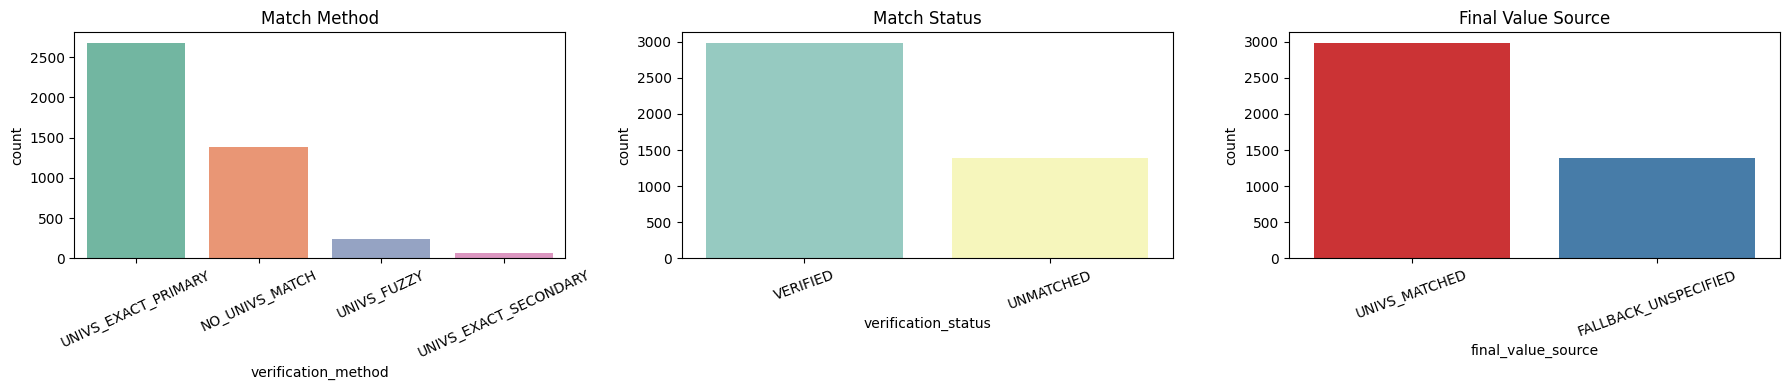

,verification_method,count
0,UNIVS_EXACT_PRIMARY,2674
1,NO_UNIVS_MATCH,1386
2,UNIVS_FUZZY,235
3,UNIVS_EXACT_SECONDARY,72


,verification_status,count
0,VERIFIED,2981
1,UNMATCHED,1386


,final_value_source,count
0,UNIVS_MATCHED,2981
1,FALLBACK_UNSPECIFIED,1386


In [10]:
# Cell 11 — Verification summary plots

method_summary = (
    verified_dim["verification_method"]
    .fillna("MISSING")
    .value_counts(dropna=False)
    .rename_axis("verification_method")
    .reset_index(name="count")
)

status_summary = (
    verified_dim["verification_status"]
    .fillna("MISSING")
    .value_counts(dropna=False)
    .rename_axis("verification_status")
    .reset_index(name="count")
)

source_summary = (
    verified_dim["final_value_source"]
    .fillna("MISSING")
    .value_counts(dropna=False)
    .rename_axis("final_value_source")
    .reset_index(name="count")
)

method_summary.to_csv(OUTDIR / "04b_verification_method_summary.csv", index=False)
status_summary.to_csv(OUTDIR / "04c_verification_status_summary.csv", index=False)
source_summary.to_csv(OUTDIR / "04d_final_value_source_summary.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=method_summary, x="verification_method", y="count", ax=axes[0], palette="Set2")
axes[0].set_title("Match Method")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=status_summary, x="verification_status", y="count", ax=axes[1], palette="Set3")
axes[1].set_title("Match Status")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=source_summary, x="final_value_source", y="count", ax=axes[2], palette="Set1")
axes[2].set_title("Final Value Source")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(OUTDIR / "04_matching_summary_plots.png", dpi=200, bbox_inches="tight")
plt.show()

display(method_summary)
display(status_summary)
display(source_summary)

### Cell 12 — Finalize verified university dimension

In [11]:
# Cell 12 — Reload DsPy_verified.csv and confirm structure for downstream cells

verified_dim = pd.read_csv(DSPY_VERIFIED_PATH, dtype=str)

for col in [
    "NMA_College", "NMA_College_norm", "School Type_rec2_FINAL",
    "UNIVERSITY", "UNI_TYPE", "UNI_LOCATION",
    "UNIVERSITY_VERIFIED", "UNI_TYPE_VERIFIED", "UNI_LOCATION_VERIFIED",
    "final_value_source", "verification_method", "verification_status",
    "confidence", "evidence_summary",
    "draft_university", "draft_uni_type", "draft_uni_location",
    "draft_hint_method"
]:
    if col in verified_dim.columns:
        verified_dim[col] = verified_dim[col].map(clean_text)

# Re-canonicalize after reload (ensures type consistency)
verified_dim["UNI_TYPE"] = verified_dim.apply(
    lambda r: canon_uni_type_final(r.get("UNI_TYPE"), r.get("School Type_rec2_FINAL")),
    axis=1
)
verified_dim["UNI_LOCATION"] = verified_dim.apply(
    lambda r: canon_uni_location_final(r.get("UNI_LOCATION"), r.get("UNI_TYPE")),
    axis=1
)

# Ensure verified columns are only populated for VERIFIED rows
is_verified = verified_dim["verification_status"].eq("VERIFIED")
verified_dim["UNIVERSITY_VERIFIED"]   = np.where(is_verified, verified_dim["UNIVERSITY"], np.nan)
verified_dim["UNI_TYPE_VERIFIED"]     = np.where(is_verified, verified_dim["UNI_TYPE"],   np.nan)
verified_dim["UNI_LOCATION_VERIFIED"] = np.where(is_verified, verified_dim["UNI_LOCATION"], np.nan)

# Final fallback for UNMATCHED rows:
# UNIVERSITY = original NMA_College, UNI_TYPE = Not Specified, UNI_LOCATION = Unknown
verified_dim["UNIVERSITY"] = verified_dim["UNIVERSITY"].fillna(verified_dim["NMA_College"])
verified_dim["UNI_TYPE"]   = verified_dim["UNI_TYPE"].fillna("Not Specified")
verified_dim["UNI_LOCATION"] = verified_dim["UNI_LOCATION"].fillna("Unknown")

verified_dim.to_csv(DSPY_VERIFIED_PATH, index=False)

print("✅ verified_dim reloaded and finalized.")
print(f"   Total rows:          {len(verified_dim):,}")
print(f"   VERIFIED:            {is_verified.sum():,}")
print(f"   UNMATCHED:           {(~is_verified).sum():,}")
print(f"   Columns:             {list(verified_dim.columns)}")

verified_dim.head(10)

✅ verified_dim reloaded and finalized.
   Total rows:          4,367
   VERIFIED:            2,981
   UNMATCHED:           1,386
   Columns:             ['NMA_College', 'NMA_College_norm', 'School Type_rec2_FINAL', 'nmat_count', 'UNIVERSITY', 'UNI_TYPE', 'UNI_LOCATION', 'UNIVERSITY_VERIFIED', 'UNI_TYPE_VERIFIED', 'UNI_LOCATION_VERIFIED', 'final_value_source', 'verification_method', 'verification_status', 'confidence', 'evidence_summary', 'draft_university', 'draft_uni_type', 'draft_uni_location', 'draft_hint_method', 'draft_hint_score']


,NMA_College,NMA_College_norm,School Type_rec2_FINAL,nmat_count,UNIVERSITY,UNI_TYPE,UNI_LOCATION,UNIVERSITY_VERIFIED,UNI_TYPE_VERIFIED,UNI_LOCATION_VERIFIED,final_value_source,verification_method,verification_status,confidence,evidence_summary,draft_university,draft_uni_type,draft_uni_location,draft_hint_method,draft_hint_score
0,University Of Santo Tomas,UNIVERSITY OF SANTO TOMAS,Private,25336,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVS_EXACT_PRIMARY,100.0
1,Ateneo De Manila University,ATENEO DE MANILA UNIVERSITY,Private,939,ATENEO DE MANILA UNIVERSITY,Private,Local,ATENEO DE MANILA UNIVERSITY,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,ATENEO DE MANILA UNIVERSITY,Private,Local,UNIVS_EXACT_PRIMARY,100.0
2,University Of The Philippines - Diliman,UNIVERSITY OF THE PHILIPPINES DILIMAN,Public,4416,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_EXACT_PRIMARY,100.0
3,Adventist University Of The Philippines,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,905,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,UNIVS_EXACT_PRIMARY,100.0
4,De La Salle University - Manila,DE LA SALLE UNIVERSITY MANILA,Private,2979,DE LA SALLE UNIVERSITY - MANILA,Private,Local,DE LA SALLE UNIVERSITY - MANILA,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,DE LA SALLE UNIVERSITY - MANILA,Private,Local,UNIVS_EXACT_PRIMARY,100.0
5,University Of The Philippines - Baguio City,UNIVERSITY OF THE PHILIPPINES BAGUIO CITY,Public,240,UNIVERSITY OF THE PHILIPPINES - BAGUIO CITY,Public,Local,UNIVERSITY OF THE PHILIPPINES - BAGUIO CITY,Public,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF THE PHILIPPINES - BAGUIO CITY,Public,Local,UNIVS_EXACT_PRIMARY,100.0
6,"Far Eastern University - Nrmf (Fairview, Q.C.)",FAR EASTERN UNIVERSITY NRMF FAIRVIEW Q C,Private,469,FAR EASTERN UNIVERSITY - NRMF (FAIRVIEW Q.C.),Private,Local,FAR EASTERN UNIVERSITY - NRMF (FAIRVIEW Q.C.),Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,FAR EASTERN UNIVERSITY - NRMF (FAIRVIEW Q.C.),Private,Local,UNIVS_EXACT_PRIMARY,100.0
7,"University Of San Carlos, Cebu City",UNIVERSITY OF SAN CARLOS CEBU CITY,Private,167,UNIVERSITY OF SAN CARLOS CEBU CITY,Private,Local,UNIVERSITY OF SAN CARLOS CEBU CITY,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF SAN CARLOS CEBU CITY,Private,Local,UNIVS_EXACT_PRIMARY,100.0
8,"Centro Escolar University - Mendiola, Manila",CENTRO ESCOLAR UNIVERSITY MENDIOLA MANILA,Private,445,CENTRO ESCOLAR UNIVERSITY - MENDIOLA MANILA,Private,Local,CENTRO ESCOLAR UNIVERSITY - MENDIOLA MANILA,Private,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,CENTRO ESCOLAR UNIVERSITY - MENDIOLA MANILA,Private,Local,UNIVS_EXACT_PRIMARY,100.0
9,University Of The Philippines - Manila,UNIVERSITY OF THE PHILIPPINES MANILA,Public,4890,UNIVERSITY OF THE PHILIPPINES - MANILA,Public,Local,UNIVERSITY OF THE PHILIPPINES - MANILA,Public,Local,UNIVS_MATCHED,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,UNIVERSITY OF THE PHILIPPINES - MANILA,Public,Local,UNIVS_EXACT_PRIMARY,100.0


### Cell 13 — Derive CEM raw-score validation fields

In [12]:
raw_cols = ["STU_RS_CA01", "STU_RS_CA02", "STU_RS_CA03", "STU_RS_CA04", "STU_RS_CA05", "STU_RS_CA06", "STU_RS_CA07", "STU_RS_CA08"]
std_cols = ["STU_SS_CA01", "STU_SS_CA02", "STU_SS_CA03", "STU_SS_CA04", "STU_SS_CA05", "STU_SS_CA06", "STU_SS_CA07", "STU_SS_CA08"]
part1_cols = ["STU_RS_CA01", "STU_RS_CA02", "STU_RS_CA03", "STU_RS_CA04"]
part2_cols = ["STU_RS_CA05", "STU_RS_CA06", "STU_RS_CA07", "STU_RS_CA08"]

numeric_cols = raw_cols + std_cols + [
    "STU_RSCORE",
    "STU_RSCORE_CALC",
    "STU_SS_APT",
    "STU_SS_SA",
    "STU_SSCORE",
    "STU_PRANK",
    "NMAT_YEAR",
    "AGE"
]

for col in numeric_cols:
    if col in cem.columns:
        cem[col + "_num"] = to_num(cem[col])

cem["raw_component_count"] = cem[[c + "_num" for c in raw_cols]].notna().sum(axis=1)

cem["PartIRawScoreTRUE"] = np.where(
    cem[[c + "_num" for c in part1_cols]].notna().all(axis=1),
    cem[[c + "_num" for c in part1_cols]].sum(axis=1),
    np.nan
)

cem["PartIIRawScoreTRUE"] = np.where(
    cem[[c + "_num" for c in part2_cols]].notna().all(axis=1),
    cem[[c + "_num" for c in part2_cols]].sum(axis=1),
    np.nan
)

cem["TotalRawScoreTRUE"] = np.where(
    cem[[c + "_num" for c in raw_cols]].notna().all(axis=1),
    cem[[c + "_num" for c in raw_cols]].sum(axis=1),
    np.nan
)

cem["AllRawComponentsPresent"] = cem[[c + "_num" for c in raw_cols]].notna().all(axis=1)
cem["StoredRawTotal"] = cem["STU_RSCORE_num"] if "STU_RSCORE_num" in cem.columns else np.nan
cem["CalculatedRawTotal_Source"] = cem["STU_RSCORE_CALC_num"] if "STU_RSCORE_CALC_num" in cem.columns else np.nan

cem["StoredVsDerivedMismatch"] = np.where(
    cem["AllRawComponentsPresent"] & pd.Series(cem["StoredRawTotal"]).notna(),
    cem["StoredRawTotal"] != cem["TotalRawScoreTRUE"],
    np.nan
)

cem["CalcVsDerivedMismatch"] = np.where(
    cem["AllRawComponentsPresent"] & pd.Series(cem["CalculatedRawTotal_Source"]).notna(),
    cem["CalculatedRawTotal_Source"] != cem["TotalRawScoreTRUE"],
    np.nan
)

if "STU_RSCORE_VALID" in cem.columns:
    cem["STU_RSCORE_VALID_clean"] = cem["STU_RSCORE_VALID"].astype(str).str.upper().str.strip()
    cem.loc[cem["STU_RSCORE_VALID"].isna(), "STU_RSCORE_VALID_clean"] = np.nan
else:
    cem["STU_RSCORE_VALID_clean"] = np.nan

raw_validation = pd.DataFrame({
    "metric": [
        "cem_rows",
        "cem_unique_STU_NO",
        "all_raw_components_present",
        "stored_total_available",
        "calc_total_available",
        "stored_vs_derived_mismatch",
        "calc_vs_derived_mismatch"
    ],
    "value": [
        len(cem),
        cem["STU_NO_clean"].nunique(dropna=True),
        int(cem["AllRawComponentsPresent"].sum()),
        int(pd.Series(cem["StoredRawTotal"]).notna().sum()),
        int(pd.Series(cem["CalculatedRawTotal_Source"]).notna().sum()),
        int(pd.Series(cem["StoredVsDerivedMismatch"]).fillna(False).sum()),
        int(pd.Series(cem["CalcVsDerivedMismatch"]).fillna(False).sum())
    ]
})

raw_validation.to_csv(OUTDIR / "05_raw_score_validation_summary.csv", index=False)
raw_validation

,metric,value
0,cem_rows,254308
1,cem_unique_STU_NO,254304
2,all_raw_components_present,254308
3,stored_total_available,174494
4,calc_total_available,254308
5,stored_vs_derived_mismatch,107422
6,calc_vs_derived_mismatch,0


### Cell 14 — Deduplicate CEM on applicant key before merge

In [13]:
cem["valid_priority"] = np.where(cem["STU_RSCORE_VALID_clean"] == "VALID", 1, 0)
cem["stored_total_present"] = cem["StoredRawTotal"].notna().astype(int)
cem["calc_total_present"] = cem["CalculatedRawTotal_Source"].notna().astype(int)

cem_sorted = cem.sort_values(
    by=["valid_priority", "raw_component_count", "calc_total_present", "stored_total_present", "NMAT_YEAR_num"],
    ascending=[False, False, False, False, False]
).copy()

cem_dups = cem_sorted[cem_sorted["STU_NO_clean"].duplicated(keep=False)].copy()
cem_dups.to_csv(OUTDIR / "06_cem_duplicate_keys_detail.csv", index=False)

cem_best = cem_sorted.drop_duplicates(subset=["STU_NO_clean"], keep="first").copy()

print("CEM rows:", len(cem))
print("CEM unique applicant keys:", cem["STU_NO_clean"].nunique(dropna=True))
print("CEM deduplicated rows:", len(cem_best))

CEM rows: 254308
CEM unique applicant keys: 254304
CEM deduplicated rows: 254304


### Cell 15 — Merge verified university dimension into NMAT base

In [14]:
# Cell 15 — Merge verified university dimension into NMAT base

nmat_base = nmat.copy()

verified_merge_cols = [
    "NMA_College",
    "UNIVERSITY",
    "UNI_TYPE",
    "UNI_LOCATION",
    "UNIVERSITY_VERIFIED",
    "UNI_TYPE_VERIFIED",
    "UNI_LOCATION_VERIFIED",
    "final_value_source",
    "draft_university",
    "draft_uni_type",
    "draft_uni_location",
    "draft_hint_method",
    "draft_hint_score",
    "verification_method",
    "verification_status",
    "confidence",
    "evidence_summary"
]

nmat_base = nmat_base.merge(
    verified_dim[verified_merge_cols].drop_duplicates(subset=["NMA_College"]),
    on="NMA_College",
    how="left",
    indicator="merge_verified_university"
)

nmat_base["NMA_College_RAW"] = nmat_base["NMA_College"]

nmat_base["UNIVERSITY"] = nmat_base["UNIVERSITY"].fillna(nmat_base["NMA_College_RAW"])

nmat_base["UNI_TYPE"] = nmat_base["UNI_TYPE"].fillna(
    nmat_base["School Type_rec2_FINAL"].map(lambda x: canon_uni_type_final(np.nan, x))
)

nmat_base["UNI_LOCATION"] = nmat_base.apply(
    lambda r: r["UNI_LOCATION"] if pd.notna(r["UNI_LOCATION"])
    else canon_uni_location_final(np.nan, r.get("UNI_TYPE")),
    axis=1
)

nmat_base["CourseGroup"] = nmat_base.apply(derive_course_group, axis=1)

nmat_base["NMS_PER_num"] = to_num(nmat_base["NMS_PER"])
nmat_base["PercentileBin"] = pd.cut(
    nmat_base["NMS_PER_num"],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 101],
    labels=["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B9", "B10"],
    right=False,
    include_lowest=True
)

nmat_base.head(10)

,Year,NMA_TestDate,NMC_Center,NMA_AppNo,NMA_Name,NMA_Course,NMA_Sex,NMA_BirthDate,NAC_NATIONALITY,NMA_Graduating,NMA_YearGrad,NMS_VCss,NMS_IRss,NMS_Qss,NMS_PAss,NMS_BIOss,NMS_PHYss,NMS_SSCss,NMS_CHEMss,NMS_APT,NMS_SA,NMS_GPS,NMS_PER,NMAT Province local address,NMAT Region permanent address,NMA_College,School Type_rec2_FINAL,Course Classification,Course_recode,SOURCE_NMAT,NMA_AppNo_clean,NMA_College_norm,UNIVERSITY,UNI_TYPE,UNI_LOCATION,UNIVERSITY_VERIFIED,UNI_TYPE_VERIFIED,UNI_LOCATION_VERIFIED,final_value_source,draft_university,draft_uni_type,draft_uni_location,draft_hint_method,draft_hint_score,verification_method,verification_status,confidence,evidence_summary,merge_verified_university,NMA_College_RAW,CourseGroup,NMS_PER_num,PercentileBin
0,2006,12/10/2006,Manila,1070637,"Abad, Giselle Katigbak",Education & Teacher Training Education,2,00/00/0000,Filipino,0,2006,512,461,599,526,461,481,497,374,539,454,489,46,Rizal,Region IV-A,University Of Santo Tomas,Private,Education & Teacher Training,Education,NMAT_CLEANED_DATA,1070637,UNIVERSITY OF SANTO TOMAS,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVS_MATCHED,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVS_EXACT_PRIMARY,100.0,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,both,University Of Santo Tomas,Education,46.0,B5
1,2006,4/9/2006,Manila,1060350,"Abad, Timothy Joseph Galimba",General Arts,1,00/00/0000,Filipino,0,2007,726,584,570,473,652,601,652,634,624,672,650,93,Ncr,NCR,Ateneo De Manila University,Private,General,Arts,NMAT_CLEANED_DATA,1060350,ATENEO DE MANILA UNIVERSITY,ATENEO DE MANILA UNIVERSITY,Private,Local,ATENEO DE MANILA UNIVERSITY,Private,Local,UNIVS_MATCHED,ATENEO DE MANILA UNIVERSITY,Private,Local,UNIVS_EXACT_PRIMARY,100.0,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,both,Ateneo De Manila University,Other,93.0,B10
2,2006,4/9/2006,Manila,1060229,"Abadam, Edelyn Joy Macadaan",Education & Teacher Training Teacher Training ...,2,00/00/0000,Filipino,0,2007,529,617,652,423,570,617,542,556,588,594,589,81,Bulacan,Region III,University Of The Philippines - Diliman,Public,Education & Teacher Training,Teacher Training for Teaching Pre-school or Ki...,NMAT_CLEANED_DATA,1060229,UNIVERSITY OF THE PHILIPPINES DILIMAN,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_MATCHED,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_EXACT_PRIMARY,100.0,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,both,University Of The Philippines - Diliman,Education,81.0,B9
3,2006,12/10/2006,Manila,1071890,"Abadam, Edelyn Joy Macadaan",Education & Teacher Training Teacher Training ...,2,00/00/0000,Filipino,0,2007,541,659,675,481,512,526,675,541,611,577,604,85,Bulacan,Region III,University Of The Philippines - Diliman,Public,Education & Teacher Training,Teacher Training for Teaching Pre-school or Ki...,NMAT_CLEANED_DATA,1071890,UNIVERSITY OF THE PHILIPPINES DILIMAN,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_MATCHED,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_EXACT_PRIMARY,100.0,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,both,University Of The Philippines - Diliman,Education,85.0,B9
4,2006,4/9/2006,Manila,1052985,"Abadilla, Giselle Marie Tercero",Education & Teacher Training Education,2,00/00/0000,Filipino,0,2001,380,542,556,323,515,500,570,556,433,546,497,49,Isabela,Region II,Adventist University Of The Philippines,Private,Education & Teacher Training,Education,NMAT_CLEANED_DATA,1052985,ADVENTIST UNIVERSITY OF THE PHILIPPINES,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,UNIVS_MATCHED,ADVENTIST UNIVERSITY OF THE PHILIPPINES,Private,Local,UNIVS_EXACT_PRIMARY,100.0,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched fr

### Cell 16 — Left join CEM enrichment into NMAT base on applicant number

In [15]:
# Cell 16 — Left join CEM enrichment into NMAT base on applicant number
# ALL CEM columns included — full join, nothing left behind

cem_merge_cols = [
    "STU_NO_clean",

    # ── CEM Demographic fields (not in NMAT) ──────────────────────
    "BDATE",
    "AGE",
    "SEX",
    "CIVIL_STATUS",

    # ── CEM College / Course (raw, uncleaned CEM version) ─────────
    "COLLEGE_NAME",
    "COURSE_DESC",

    # ── Medical school choices ─────────────────────────────────────
    "MED_SCHOOL_CHOICE1",
    "MED_SCHOOL_CHOICE2",
    "MED_SCHOOL_CHOICE3",

    # ── Test date and year from CEM ────────────────────────────────
    "STU_TESTDATE",
    "NMAT_YEAR",

    # ── Raw score validity flag ────────────────────────────────────
    "STU_RSCORE_VALID",

    # ── Original stored totals (string/raw as-is from CEM) ────────
    # These are preserved alongside the _num versions for audit trail
    "STU_RSCORE",         # original stored total raw score string
    "STU_RSCORE_CALC",    # original calculated raw score string

    # ── Derived / validated score totals ──────────────────────────
    "StoredRawTotal",               # numeric version of STU_RSCORE
    "CalculatedRawTotal_Source",    # numeric version of STU_RSCORE_CALC
    "TotalRawScoreTRUE",            # sum of 8 component raws (derived)
    "PartIRawScoreTRUE",            # Part I sum (derived)
    "PartIIRawScoreTRUE",           # Part II sum (derived)

    # ── Mismatch flags ─────────────────────────────────────────────
    "AllRawComponentsPresent",
    "StoredVsDerivedMismatch",
    "CalcVsDerivedMismatch",
    "raw_component_count",

    # ── Raw score components (numeric) ────────────────────────────
    "STU_RS_CA01_num",   # Verbal raw
    "STU_RS_CA02_num",   # Inductive Reasoning raw
    "STU_RS_CA03_num",   # Quantitative raw
    "STU_RS_CA04_num",   # Perceptual Acuity raw
    "STU_RS_CA05_num",   # Biology raw
    "STU_RS_CA06_num",   # Physics raw
    "STU_RS_CA07_num",   # Social Science raw
    "STU_RS_CA08_num",   # Chemistry raw

    # ── Standard score components from CEM (numeric) ───────────────
    "STU_SS_CA01_num",   # Verbal SS
    "STU_SS_CA02_num",   # Inductive Reasoning SS
    "STU_SS_CA03_num",   # Quantitative SS
    "STU_SS_CA04_num",   # Perceptual Acuity SS
    "STU_SS_CA05_num",   # Biology SS
    "STU_SS_CA06_num",   # Physics SS
    "STU_SS_CA07_num",   # Social Science SS
    "STU_SS_CA08_num",   # Chemistry SS

    # ── CEM composite scores (numeric) ────────────────────────────
    "STU_SS_APT_num",    # Aptitude composite (Part I)
    "STU_SS_SA_num",     # Subject Area composite (Part II)
    "STU_SSCORE_num",    # General Performance Score (CEM)
    "STU_PRANK_num",     # Percentile Rank (CEM)

    # ── Unique CEM record key ──────────────────────────────────────
    "KEY"
]

# Only keep cols that actually exist in cem_best (safety guard)
cem_merge_cols = [c for c in cem_merge_cols if c in cem_best.columns]

nmat_master = nmat_base.merge(
    cem_best[cem_merge_cols],
    left_on="NMA_AppNo_clean",
    right_on="STU_NO_clean",
    how="left",
    indicator="merge_cem"
)

nmat_master["HasCEMMatch"]      = nmat_master["merge_cem"].eq("both")
nmat_master["HasTRUErawScores"] = nmat_master["AllRawComponentsPresent"].fillna(False)

assert len(nmat_master) == len(nmat_base), "Row count changed after left join. Investigate duplicate keys."

print("Final master rows:", len(nmat_master))
print("Matched to CEM:", int(nmat_master["HasCEMMatch"].sum()))
print("With complete TRUE raw scores:", int(nmat_master["HasTRUErawScores"].sum()))
print("\nCEM columns pulled in:", len(cem_merge_cols))
print("Total columns in master:", len(nmat_master.columns))

Final master rows: 178927
Matched to CEM: 178882
With complete TRUE raw scores: 178882

CEM columns pulled in: 45
Total columns in master: 101


### Cell 17 — Validation summaries and merge plots

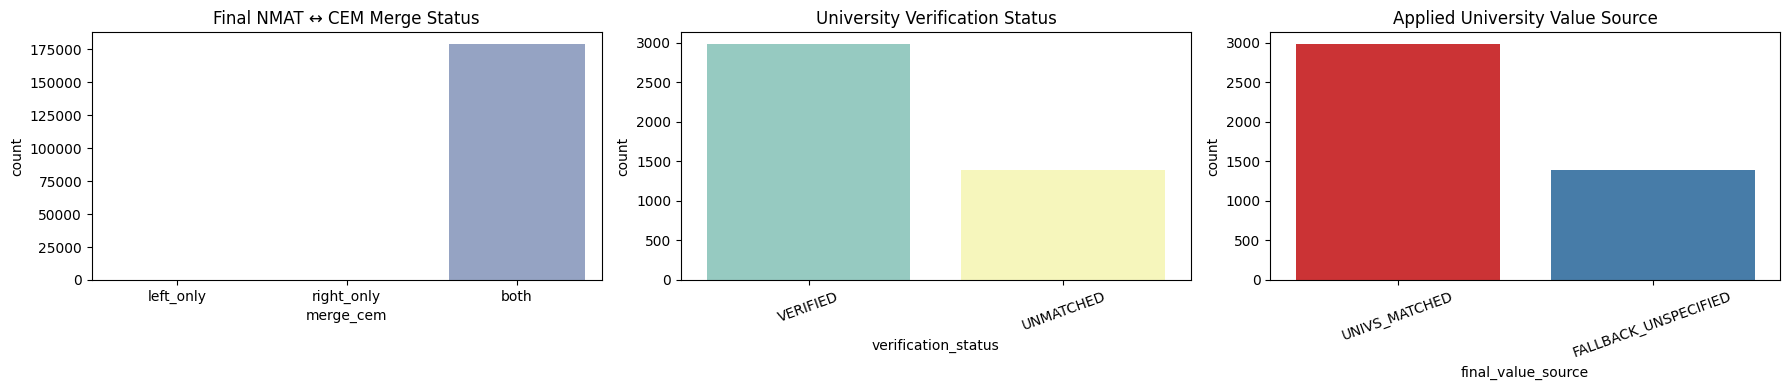

,metric,value
0,NMAT_base_rows,178927
1,NMAT_base_unique_appno,178926
2,CEM_rows_raw,254308
3,CEM_rows_deduped,254304
4,CEM_unique_appno,254304
5,NMAT_rows_after_final_merge,178927
6,Matched_to_CEM,178882
7,Has_TRUE_raw_scores,178882


In [16]:
# Cell 17 — Validation summaries and merge plots

merge_summary = pd.DataFrame({
    "metric": [
        "NMAT_base_rows",
        "NMAT_base_unique_appno",
        "CEM_rows_raw",
        "CEM_rows_deduped",
        "CEM_unique_appno",
        "NMAT_rows_after_final_merge",
        "Matched_to_CEM",
        "Has_TRUE_raw_scores"
    ],
    "value": [
        len(nmat_base),
        nmat_base["NMA_AppNo_clean"].nunique(dropna=True),
        len(cem),
        len(cem_best),
        cem_best["STU_NO_clean"].nunique(dropna=True),
        len(nmat_master),
        int(nmat_master["HasCEMMatch"].sum()),
        int(nmat_master["HasTRUErawScores"].sum())
    ]
})
merge_summary.to_csv(OUTDIR / "07_merge_summary.csv", index=False)

merge_indicator = (
    nmat_master["merge_cem"]
    .value_counts(dropna=False)
    .rename_axis("merge_cem")
    .reset_index(name="count")
)
merge_indicator.to_csv(OUTDIR / "08_merge_indicator_counts.csv", index=False)

verif_plot = (
    verified_dim["verification_status"]
    .fillna("MISSING")
    .value_counts(dropna=False)
    .rename_axis("verification_status")
    .reset_index(name="count")
)

value_source_plot = (
    verified_dim["final_value_source"]
    .fillna("MISSING")
    .value_counts(dropna=False)
    .rename_axis("final_value_source")
    .reset_index(name="count")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=merge_indicator, x="merge_cem", y="count", ax=axes[0], palette="Set2")
axes[0].set_title("Final NMAT ↔ CEM Merge Status")

sns.barplot(data=verif_plot, x="verification_status", y="count", ax=axes[1], palette="Set3")
axes[1].set_title("University Verification Status")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=value_source_plot, x="final_value_source", y="count", ax=axes[2], palette="Set1")
axes[2].set_title("Applied University Value Source")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(OUTDIR / "09_merge_and_verification_plots.png", dpi=200, bbox_inches="tight")
plt.show()

merge_summary

### Cell 18 — Final cleanup and export NMAT_FINAL.csv

In [17]:
# Cell 18 — Final cleanup and export NMAT_FINAL.csv

rename_map = {
    # Raw score components
    "STU_RS_CA01_num": "Raw_Verbal",
    "STU_RS_CA02_num": "Raw_InductiveReasoning",
    "STU_RS_CA03_num": "Raw_Quantitative",
    "STU_RS_CA04_num": "Raw_PerceptualAcuity",
    "STU_RS_CA05_num": "Raw_Biology",
    "STU_RS_CA06_num": "Raw_Physics",
    "STU_RS_CA07_num": "Raw_SocialScience",
    "STU_RS_CA08_num": "Raw_Chemistry",
    # Standard score components (CEM)
    "STU_SS_CA01_num": "Std_Verbal_CEM",
    "STU_SS_CA02_num": "Std_InductiveReasoning_CEM",
    "STU_SS_CA03_num": "Std_Quantitative_CEM",
    "STU_SS_CA04_num": "Std_PerceptualAcuity_CEM",
    "STU_SS_CA05_num": "Std_Biology_CEM",
    "STU_SS_CA06_num": "Std_Physics_CEM",
    "STU_SS_CA07_num": "Std_SocialScience_CEM",
    "STU_SS_CA08_num": "Std_Chemistry_CEM",
    # CEM composites
    "STU_SS_APT_num": "APT_CEM",
    "STU_SS_SA_num":  "SA_CEM",
    "STU_SSCORE_num": "GPS_CEM",
    "STU_PRANK_num":  "Percentile_CEM"
}

nmat_master = nmat_master.rename(columns=rename_map)

priority_cols = [
    # ── Identifiers ───────────────────────────────────────────────
    "Year",
    "NMA_TestDate",
    "NMA_AppNo",
    "NMA_AppNo_clean",
    "NMA_Name",

    # ── NMAT Demographics ─────────────────────────────────────────
    "NMA_Sex",          # from NMAT (1=Male, 2=Female coded)
    "NMA_BirthDate",    # from NMAT

    # ── CEM Demographics (enriched from CEM join) ─────────────────
    "BDATE",            # date of birth from CEM
    "AGE",              # age from CEM
    "SEX",              # gender from CEM (text: Male/Female)
    "CIVIL_STATUS",     # civil status from CEM

    # ── Nationality / Enrollment ───────────────────────────────────
    "NAC_NATIONALITY",
    "NMA_Graduating",
    "NMA_YearGrad",

    # ── Course / Background ────────────────────────────────────────
    "NMA_Course",
    "Course Classification",
    "Course_recode",
    "CourseGroup",

    # ── Medical School Choices (from CEM) ─────────────────────────
    "MED_SCHOOL_CHOICE1",
    "MED_SCHOOL_CHOICE2",
    "MED_SCHOOL_CHOICE3",

    # ── University (verified) ──────────────────────────────────────
    "NMA_College_RAW",
    "UNIVERSITY",
    "UNI_TYPE",
    "UNI_LOCATION",
    "UNIVERSITY_VERIFIED",
    "UNI_TYPE_VERIFIED",
    "UNI_LOCATION_VERIFIED",
    "final_value_source",
    "draft_university",
    "draft_uni_type",
    "draft_uni_location",
    "draft_hint_method",
    "draft_hint_score",
    "verification_method",
    "verification_status",
    "confidence",
    "evidence_summary",
    "School Type_rec2_FINAL",

    # ── Geography ─────────────────────────────────────────────────
    "NMC_Center",
    "NMAT Province local address",
    "NMAT Region permanent address",

    # ── NMAT Standard Scores ──────────────────────────────────────
    "NMS_VCss",
    "NMS_IRss",
    "NMS_Qss",
    "NMS_PAss",
    "NMS_BIOss",
    "NMS_PHYss",
    "NMS_SSCss",
    "NMS_CHEMss",
    "NMS_APT",
    "NMS_SA",
    "NMS_GPS",
    "NMS_PER",
    "NMS_PER_num",
    "PercentileBin",

    # ── CEM Match metadata ────────────────────────────────────────
    "HasCEMMatch",
    "HasTRUErawScores",

    # ── Raw Score Validation ──────────────────────────────────────
    "STU_RSCORE",               # original stored total string
    "STU_RSCORE_CALC",          # original calc total string
    "STU_RSCORE_VALID",         # VALID / INVALID flag
    "StoredRawTotal",           # numeric stored total
    "CalculatedRawTotal_Source",# numeric calc total
    "TotalRawScoreTRUE",        # derived sum of 8 components
    "PartIRawScoreTRUE",
    "PartIIRawScoreTRUE",

    # ── Raw Score Components ──────────────────────────────────────
    "Raw_Verbal",
    "Raw_InductiveReasoning",
    "Raw_Quantitative",
    "Raw_PerceptualAcuity",
    "Raw_Biology",
    "Raw_Physics",
    "Raw_SocialScience",
    "Raw_Chemistry",

    # ── CEM Standard Score Components ────────────────────────────
    "Std_Verbal_CEM",
    "Std_InductiveReasoning_CEM",
    "Std_Quantitative_CEM",
    "Std_PerceptualAcuity_CEM",
    "Std_Biology_CEM",
    "Std_Physics_CEM",
    "Std_SocialScience_CEM",
    "Std_Chemistry_CEM",

    # ── CEM Composite Scores ──────────────────────────────────────
    "APT_CEM",
    "SA_CEM",
    "GPS_CEM",
    "Percentile_CEM",

    # ── Mismatch / Audit Flags ────────────────────────────────────
    "AllRawComponentsPresent",
    "StoredVsDerivedMismatch",
    "CalcVsDerivedMismatch",
    "raw_component_count",

    # ── CEM Source Fields (raw, for audit) ───────────────────────
    "COLLEGE_NAME",     # raw CEM college name (before cleaning)
    "COURSE_DESC",      # raw CEM course description
    "STU_TESTDATE",     # test date from CEM
    "NMAT_YEAR",        # NMAT year from CEM
    "KEY",              # CEM unique key (anonymized)

    # ── Pipeline Provenance ───────────────────────────────────────
    "merge_verified_university",
    "merge_cem",
    "SOURCE_NMAT",
]

priority_cols = [c for c in priority_cols if c in nmat_master.columns]
other_cols    = [c for c in nmat_master.columns if c not in priority_cols]

nmat_final = nmat_master[priority_cols + other_cols].copy()

nmat_final.to_csv(FINAL_PATH, index=False)
nmat_final.to_parquet(OUTDIR / "NMAT_FINAL.parquet", index=False)

print("Saved final CSV:", FINAL_PATH)
print("Saved final Parquet:", OUTDIR / "NMAT_FINAL.parquet")
print("Final shape:", nmat_final.shape)
print("\nColumn list:")
for i, c in enumerate(nmat_final.columns):
    print(f"  {i+1:3d}. {c}")

nmat_final.head(5)

Saved final CSV: dataset\NMAT_FINAL.csv
Saved final Parquet: dataset\output\NMAT_FINAL.parquet
Final shape: (178927, 101)

Column list:
    1. Year
    2. NMA_TestDate
    3. NMA_AppNo
    4. NMA_AppNo_clean
    5. NMA_Name
    6. NMA_Sex
    7. NMA_BirthDate
    8. BDATE
    9. AGE
   10. SEX
   11. CIVIL_STATUS
   12. NAC_NATIONALITY
   13. NMA_Graduating
   14. NMA_YearGrad
   15. NMA_Course
   16. Course Classification
   17. Course_recode
   18. CourseGroup
   19. MED_SCHOOL_CHOICE1
   20. MED_SCHOOL_CHOICE2
   21. MED_SCHOOL_CHOICE3
   22. NMA_College_RAW
   23. UNIVERSITY
   24. UNI_TYPE
   25. UNI_LOCATION
   26. UNIVERSITY_VERIFIED
   27. UNI_TYPE_VERIFIED
   28. UNI_LOCATION_VERIFIED
   29. final_value_source
   30. draft_university
   31. draft_uni_type
   32. draft_uni_location
   33. draft_hint_method
   34. draft_hint_score
   35. verification_method
   36. verification_status
   37. confidence
   38. evidence_summary
   39. School Type_rec2_FINAL
   40. NMC_Center
   41.

,Year,NMA_TestDate,NMA_AppNo,NMA_AppNo_clean,NMA_Name,NMA_Sex,NMA_BirthDate,BDATE,AGE,SEX,CIVIL_STATUS,NAC_NATIONALITY,NMA_Graduating,NMA_YearGrad,NMA_Course,Course Classification,Course_recode,CourseGroup,MED_SCHOOL_CHOICE1,MED_SCHOOL_CHOICE2,MED_SCHOOL_CHOICE3,NMA_College_RAW,UNIVERSITY,UNI_TYPE,UNI_LOCATION,UNIVERSITY_VERIFIED,UNI_TYPE_VERIFIED,UNI_LOCATION_VERIFIED,final_value_source,draft_university,draft_uni_type,draft_uni_location,draft_hint_method,draft_hint_score,verification_method,verification_status,confidence,evidence_summary,School Type_rec2_FINAL,NMC_Center,NMAT Province local address,NMAT Region permanent address,NMS_VCss,NMS_IRss,NMS_Qss,NMS_PAss,NMS_BIOss,NMS_PHYss,NMS_SSCss,NMS_CHEMss,NMS_APT,NMS_SA,NMS_GPS,NMS_PER,NMS_PER_num,PercentileBin,HasCEMMatch,HasTRUErawScores,STU_RSCORE,STU_RSCORE_CALC,STU_RSCORE_VALID,StoredRawTotal,CalculatedRawTotal_Source,TotalRawScoreTRUE,PartIRawScoreTRUE,PartIIRawScoreTRUE,Raw_Verbal,Raw_InductiveReasoning,Raw_Quantitative,Raw_PerceptualAcuity,Raw_Biology,Raw_Physics,Raw_SocialScience,Raw_Chemistry,Std_Verbal_CEM,Std_InductiveReasoning_CEM,Std_Quantitative_CEM,Std_PerceptualAcuity_CEM,Std_Biology_CEM,Std_Physics_CEM,Std_SocialScience_CEM,Std_Chemistry_CEM,APT_CEM,SA_CEM,GPS_CEM,Percentile_CEM,AllRawComponentsPresent,StoredVsDerivedMismatch,CalcVsDerivedMismatch,raw_component_count,COLLEGE_NAME,COURSE_DESC,STU_TESTDATE,NMAT_YEAR,KEY,merge_verified_university,merge_cem,SOURCE_NMAT,NMA_College,NMA_College_norm,STU_NO_clean
0,2006,12/10/2006,1070637,1070637,"Abad, Giselle Katigbak",2,00/00/0000,NaN,21,Female,Single,Filipino,0,2006,Education & Teacher Training Education,Education & Teacher Training,Education,Education,Pamantasan ng Lungsod ng Maynila,University of Santo Tomas,UERM Memorial Medical Center,University Of Santo Tomas,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVS_MATCHED,UNIVERSITY OF SANTO TOMAS,Private,Local,UNIVS_EXACT_PRIMARY,100.0,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,Private,Manila,Rizal,Region IV-A,512,461,599,526,461,481,497,374,539,454,489,46,46.0,B5,True,True,NaN,125,VALID,NaN,125.0,125.0,71.0,54.0,16.0,17.0,21.0,17.0,16.0,14.0,15.0,9.0,512.0,461.0,599.0,526.0,461.0,481.0,497.0,374.0,539.0,454.0,489.0,46.0,True,NaN,0.0,8.0,University of Santo Tomas,[EDUCATION & TEACHER TRAINING] Education,'Dec06,2006,ANON_15903_261811,both,both,NMAT_CLEANED_DATA,University Of Santo Tomas,UNIVERSITY OF SANTO TOMAS,1070637
1,2006,4/9/2006,1060350,1060350,"Abad, Timothy Joseph Galimba",1,00/00/0000,NaN,20,Male,Single,Filipino,0,2007,General Arts,General,Arts,Other,UP College of Medicine (Health Sciences Center),University of Santo Tomas,St. Luke's Medical Center,Ateneo De Manila University,ATENEO DE MANILA UNIVERSITY,Private,Local,ATENEO DE MANILA UNIVERSITY,Private,Local,UNIVS_MATCHED,ATENEO DE MANILA UNIVERSITY,Private,Local,UNIVS_EXACT_PRIMARY,100.0,UNIVS_EXACT_PRIMARY,VERIFIED,100,Matched from UNIVS.csv via UNIVS_EXACT_PRIMARY...,Private,Manila,Ncr,NCR,726,584,570,473,652,601,652,634,624,672,650,93,93.0,B10,True,True,NaN,175,VALID,NaN,175.0,175.0,86.0,89.0,28.0,22.0,20.0,16.0,24.0,19.0,24.0,22.0,726.0,584.0,570.0,473.0,652.0,601.0,652.0,634.0,624.0,672.0,650.0,93.0,True,NaN,0.0,8.0,Ateneo de Manila University,[GENERAL] Arts,'Apr06,2006,ANON_26269_260134,both,both,NMAT_CLEANED_DATA,Ateneo De Manila University,ATENEO DE MANILA UNIVERSITY,1060350
2,2006,4/9/2006,1060229,1060229,"Abadam, Edelyn Joy Macadaan",2,00/00/0000,NaN,19,Female,Single,Filipino,0,2007,Education & Teacher Training Teacher Training ...,Education & Teacher Training,Teacher Training for Teaching Pre-school or Ki...,Education,UP College of Medicine (Health Sciences Center),University of Santo Tomas,UERM Memorial Medical Center,University Of The Philippines - Diliman,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Public,Local,UNIVS_MATCHED,UNIVERSITY OF THE PHILIPPINES - DILIMAN,Pub

### Cell 19 — Optional quick QA tables

In [18]:
# Cell 19 — Optional quick QA tables

qa_1 = nmat_final[["UNI_TYPE", "UNI_LOCATION"]].value_counts(dropna=False).reset_index(name="count")
qa_2 = nmat_final["CourseGroup"].value_counts(dropna=False).reset_index()
qa_2.columns = ["CourseGroup", "count"]
qa_3 = nmat_final["PercentileBin"].value_counts(dropna=False).reset_index()
qa_3.columns = ["PercentileBin", "count"]
qa_4 = nmat_final["verification_status"].value_counts(dropna=False).reset_index()
qa_4.columns = ["verification_status", "count"]
qa_5 = nmat_final["final_value_source"].value_counts(dropna=False).reset_index()
qa_5.columns = ["final_value_source", "count"]

qa_1.to_csv(OUTDIR / "10_qa_uni_type_location.csv", index=False)
qa_2.to_csv(OUTDIR / "11_qa_course_group.csv", index=False)
qa_3.to_csv(OUTDIR / "12_qa_bins.csv", index=False)
qa_4.to_csv(OUTDIR / "13_qa_verification_status.csv", index=False)
qa_5.to_csv(OUTDIR / "14_qa_final_value_source.csv", index=False)

display(qa_1.head(20))
display(qa_2)
display(qa_3.sort_values("PercentileBin"))
display(qa_4)
display(qa_5)

,UNI_TYPE,UNI_LOCATION,count
0,Private,Local,137476
1,Public,Local,37304
2,Foreign,International,2315
3,Not Specified,Unknown,1832


,CourseGroup,count
0,Medical & Allied,86140
1,Natural Sciences,55900
2,Social & Behavioral Sciences,22022
3,Other,9855
4,Education,4162
5,Engineering & Technology,848


,PercentileBin,count
0,B1,24434
1,B2,19393
3,B3,17443
2,B4,18600
5,B5,15857
6,B6,15829
9,B7,15282
8,B8,15407
7,B9,15500
4,B10,17041


,verification_status,count
0,VERIFIED,177120
1,UNMATCHED,1807


,final_value_source,count
0,UNIVS_MATCHED,177120
1,FALLBACK_UNSPECIFIED,1807
